In [1]:
%pip install -e ..

Obtaining file:///cluster/home/adelez/BOREAL-FOREST-EXPANSION
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for boreal-forest-expansion (pyproject.toml) ... done
  Created wheel for boreal-forest-expansion: filename=boreal_forest_expansion-0.1.0-0.editable-py3-none-any.whl size=3019 sha256=f73b522e15eb0b98281fa8e5123604a6f1f980c97b8f2119828f28fb8141c1d9
  Stored in directory: /tmp/pip-ephem-wheel-cache-wez_hhwh/wheels/33/36/1f/1eb3d87ab90ac9df0155d6c5260fbf518d629b608d8b09c675
Successfully built boreal-forest-expansion
  Attempting uninstall: boreal-forest-expansion
    Found existing installation: boreal-forest-expansion 0.1.0
    Uninstalling boreal-forest-expansion-0.1.0:
      Successfully uninstalled boreal-forest-expansion-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt

from boreal_forest_expansion.plotting.style import set_default_style
from boreal_forest_expansion.plotting.forcing_maps import (
    POSTPROCESSED_DIR,
    FIGURE_DIR,
    make_forcing_summary_figure,
    make_context_maps_figure,
    difference_map,
    BVOC_PAIRS,
)

set_default_style()

In [2]:
START_YEAR = 2001
END_YEAR = 2009

POSTPROCESSED_DIR

# Check files exist
expected = [
    f"CTRL_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-PD_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-PD-fBVOC_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-FUT_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-FUT-fBVOC_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
]

for fname in expected:
    path = POSTPROCESSED_DIR / fname
    print(path.name, "✓" if path.exists() else "MISSING")

CTRL_RADIATIVE_2001_2009.nc ✓
LCC-PD_RADIATIVE_2001_2009.nc ✓
LCC-PD-fBVOC_RADIATIVE_2001_2009.nc ✓
LCC-FUT_RADIATIVE_2001_2009.nc ✓
LCC-FUT-fBVOC_RADIATIVE_2001_2009.nc ✓


In [6]:
from pathlib import Path
import numpy as np
import xarray as xr

POSTPROCESSED_DIR = Path(
    "/cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics"
)

files = sorted(POSTPROCESSED_DIR.glob("*RADIATIVE*.nc"))

print(f"Found {len(files)} postprocessed files")
for f in files:
    print(f.name)

Found 5 postprocessed files
CTRL_RADIATIVE_2001_2009.nc
LCC-FUT-fBVOC_RADIATIVE_2001_2009.nc
LCC-FUT_RADIATIVE_2001_2009.nc
LCC-PD-fBVOC_RADIATIVE_2001_2009.nc
LCC-PD_RADIATIVE_2001_2009.nc


In [7]:
for f in sorted(POSTPROCESSED_DIR.glob("*RADIATIVE*.nc")):
    ds = xr.open_dataset(f)
    print("\n", f.name)

    print("has gw:", "gw" in ds)
    print("has lat:", "lat" in ds.coords)
    print("has lon:", "lon" in ds.coords)

    if "gw" in ds:
        print("gw dims:", ds["gw"].dims)
        print("gw has NaN:", bool(ds["gw"].isnull().any()))
        print("gw min/max:", float(ds["gw"].min()), float(ds["gw"].max()))

    ds.close()


 CTRL_RADIATIVE_2001_2009.nc
has gw: True
has lat: True
has lon: True
gw dims: ('lat',)
gw has NaN: False
gw min/max: 0.00013669500753099584 0.033063369317308286

 LCC-FUT-fBVOC_RADIATIVE_2001_2009.nc
has gw: True
has lat: True
has lon: True
gw dims: ('lat',)
gw has NaN: False
gw min/max: 0.00013669500753099584 0.033063369317308286

 LCC-FUT_RADIATIVE_2001_2009.nc
has gw: True
has lat: True
has lon: True
gw dims: ('lat',)
gw has NaN: False
gw min/max: 0.00013669500753099584 0.033063369317308286

 LCC-PD-fBVOC_RADIATIVE_2001_2009.nc
has gw: True
has lat: True
has lon: True
gw dims: ('lat',)
gw has NaN: False
gw min/max: 0.00013669500753099584 0.033063369317308286

 LCC-PD_RADIATIVE_2001_2009.nc
has gw: True
has lat: True
has lon: True
gw dims: ('lat',)
gw has NaN: False
gw min/max: 0.00013669500753099584 0.033063369317308286


Saved /cluster/home/adelez/BOREAL-FOREST-EXPANSION/results/figures/PD_forcing_decomposition_2001_2009.png


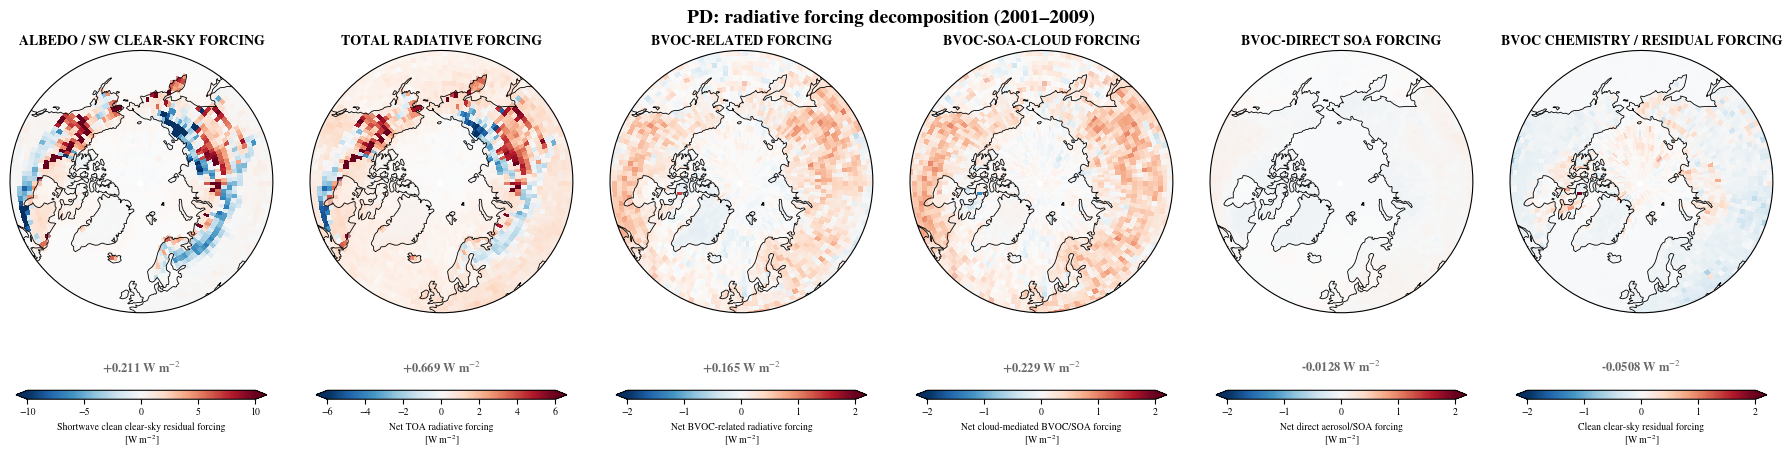

In [3]:
fig, axes = make_forcing_summary_figure(
    experiment="PD",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
)

Saved /cluster/home/adelez/BOREAL-FOREST-EXPANSION/results/figures/FUT_forcing_decomposition_2001_2009.png


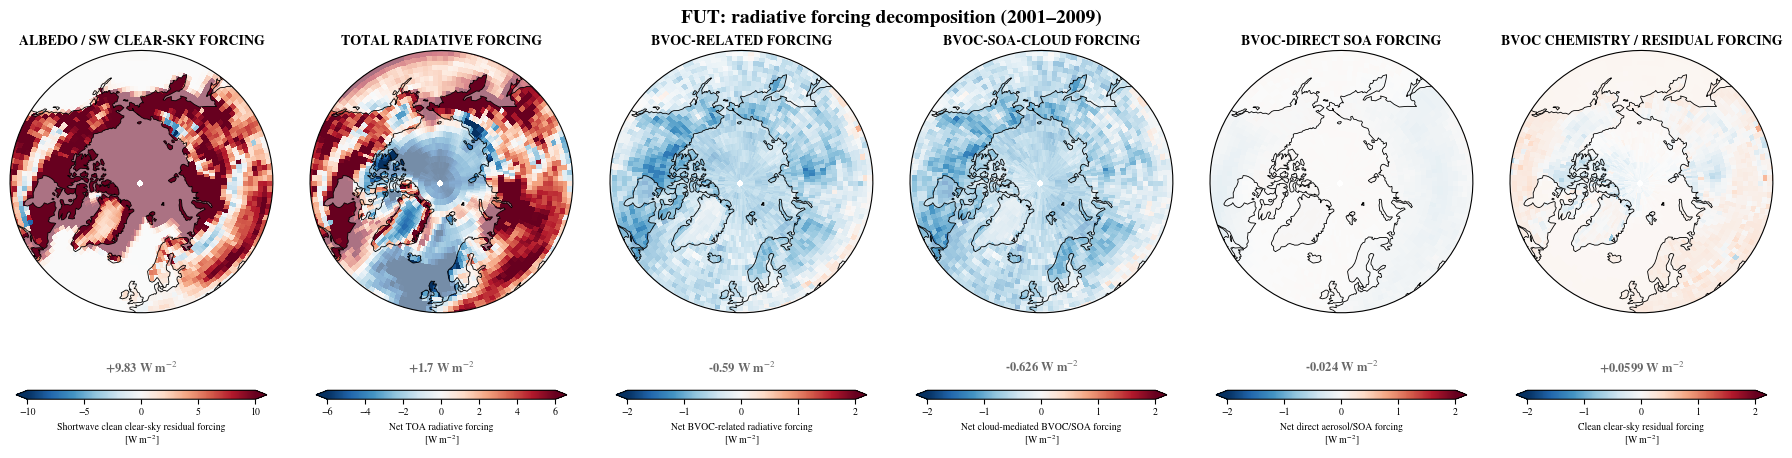

In [4]:
fig, axes = make_forcing_summary_figure(
    experiment="FUT",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
)

## BVOC/SOA/cloud mechanism maps

Skipping soa_tot: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_SOA_2001_2009.nc
Skipping n_aer: 'N_AER not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_AEROSOL_2001_2009.nc'
Skipping fctl: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping actrel: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping actnl: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping lwp: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping et: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostic

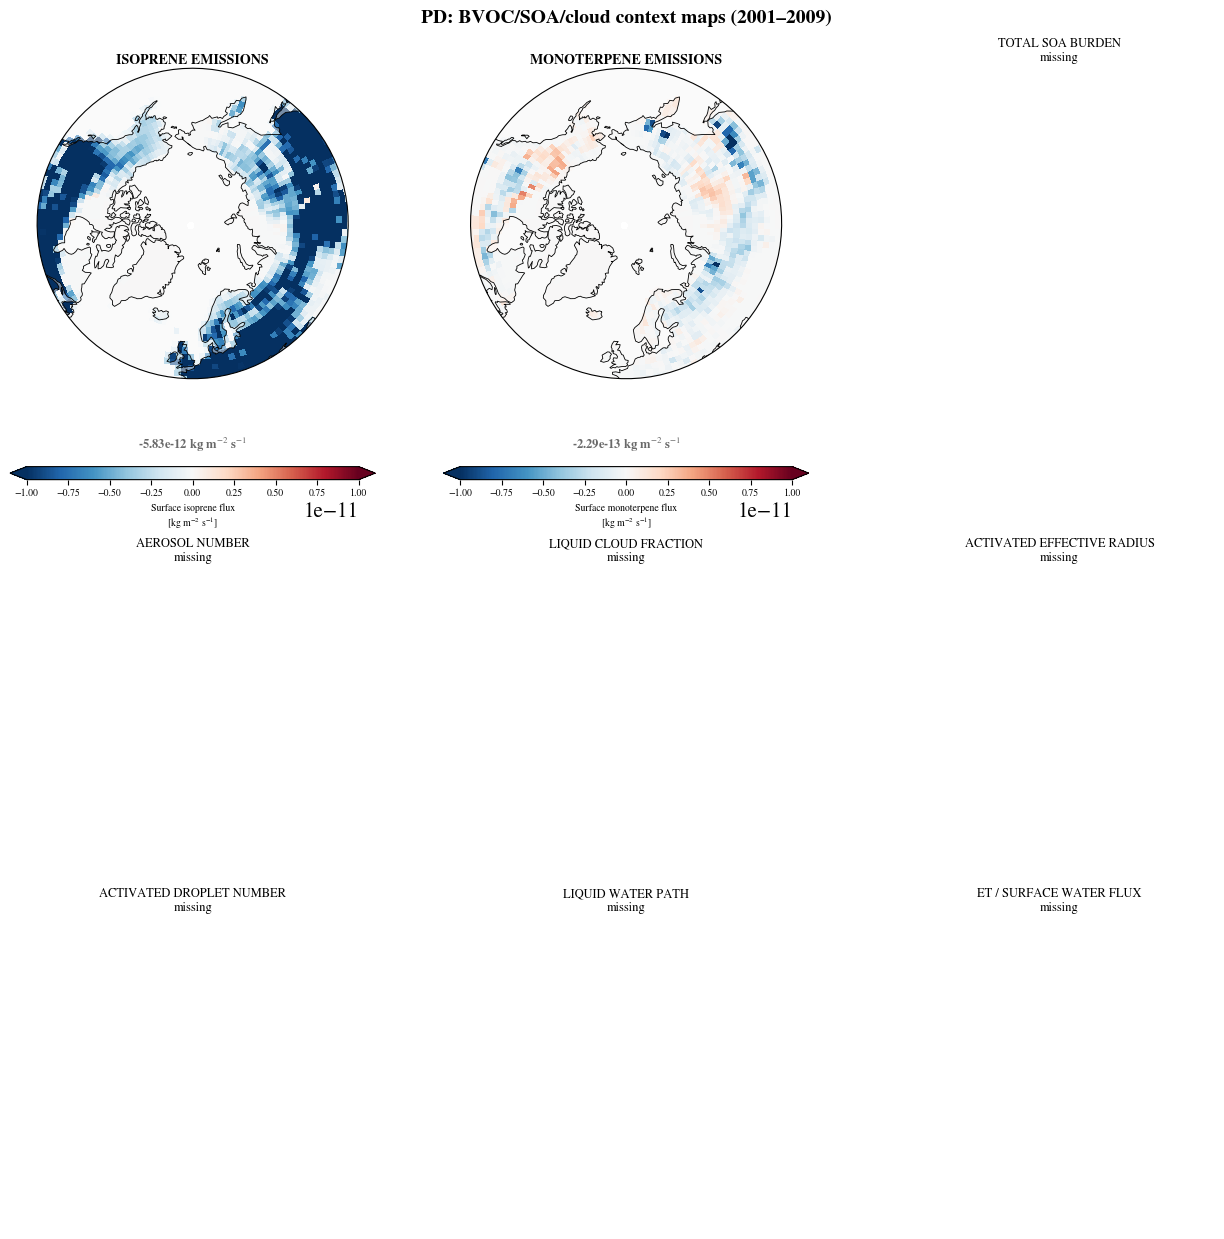

In [5]:
fig, axes = make_context_maps_figure(
    experiment="PD",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
)

Skipping soa_tot: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_SOA_2001_2009.nc
Skipping n_aer: 'N_AER not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_AEROSOL_2001_2009.nc'
Skipping fctl: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_CLOUDPROP_2001_2009.nc
Skipping actrel: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_CLOUDPROP_2001_2009.nc
Skipping actnl: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_CLOUDPROP_2001_2009.nc
Skipping lwp: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_CLOUDPROP_2001_2009.nc
Skipping et: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diag

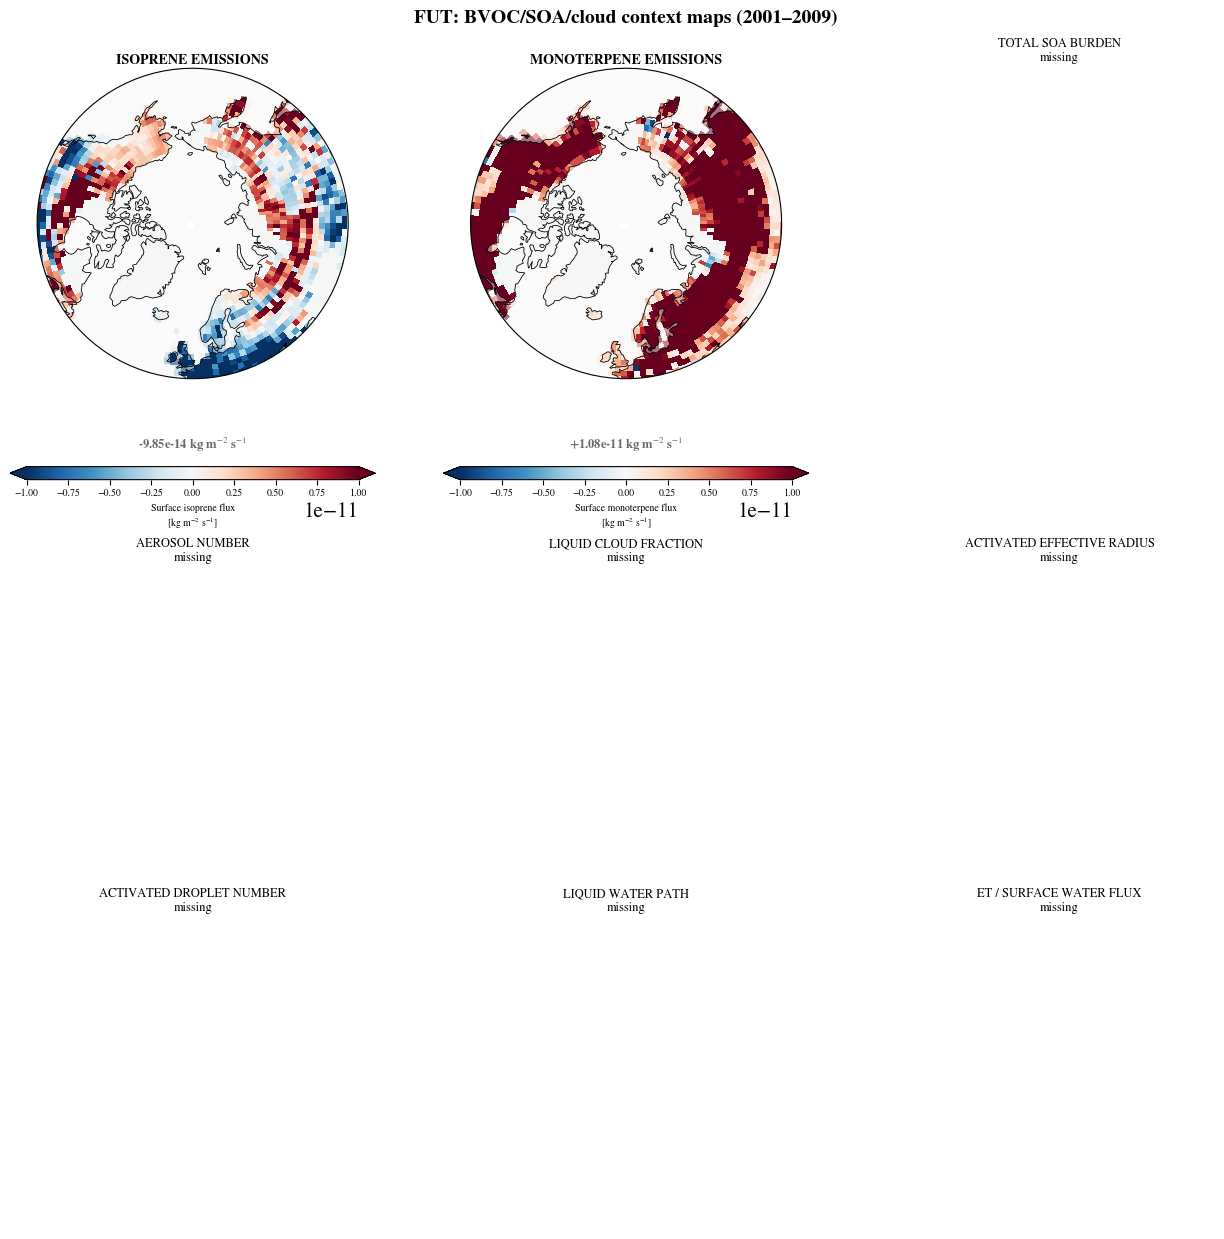

In [6]:
fig, axes = make_context_maps_figure(
    experiment="FUT",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
)

In [ ]:
da = difference_map(
    case1="LCC-PD",
    case2="LCC-PD-fBVOC",
    variable_class="RADIATIVE",
    variable="FTOT_Ghan",
    start_year=START_YEAR,
    end_year=END_YEAR,
)

da

In [ ]:
da.plot()